In [5]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import input_output
from deep_lss.utils import optimization
from deep_lss.utils.optimization import LinearWarmupCosineDecaySchedule

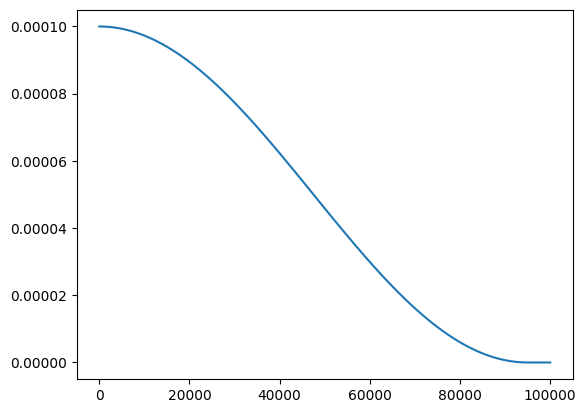

In [19]:
net_conf = input_output.read_yaml("/global/u2/a/athomsen/y3-deep-lss/configs/v7/lensing/resnet.yaml")

loss_function = "delta_loss"
learning_rate = net_conf["optimization"][loss_function]["learning_rate"]
warmup_init_learning_rate = net_conf["optimization"][loss_function]["warmup_init_learning_rate"]
warmup_steps = net_conf["optimization"][loss_function]["warmup_steps"]
decay_steps = net_conf["training"]["n_steps"] - warmup_steps
end_divided_by_init_learning_rate = net_conf["optimization"][loss_function]["decay_alpha"]

learning_rate_schedule = LinearWarmupCosineDecaySchedule(
    # warmup
    initial_learning_rate=warmup_init_learning_rate,
    warmup_steps=0,
    # warmup_steps=warmup_steps,
    warmup_target=learning_rate,
    # decay
    decay_steps=decay_steps,
    alpha=end_divided_by_init_learning_rate,
)

steps = np.linspace(0, 100000, 100, dtype=int)

lrs = []
for step in steps:
    lrs.append(learning_rate_schedule(step))
    
plt.plot(steps, lrs)

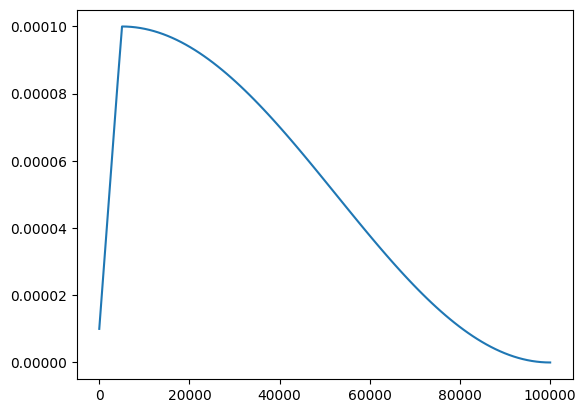

In [20]:
net_conf = input_output.read_yaml("/global/u2/a/athomsen/y3-deep-lss/configs/v7/lensing/resnet.yaml")

loss_function = "delta_loss"
learning_rate = net_conf["optimization"][loss_function]["learning_rate"]
warmup_init_learning_rate = net_conf["optimization"][loss_function]["warmup_init_learning_rate"]
warmup_steps = net_conf["optimization"][loss_function]["warmup_steps"]
decay_steps = net_conf["training"]["n_steps"] - warmup_steps
end_divided_by_init_learning_rate = net_conf["optimization"][loss_function]["decay_alpha"]

learning_rate_schedule = LinearWarmupCosineDecaySchedule(
    # warmup
    initial_learning_rate=warmup_init_learning_rate,
    # warmup_steps=0,
    warmup_steps=warmup_steps,
    warmup_target=learning_rate,
    # decay
    decay_steps=decay_steps,
    alpha=end_divided_by_init_learning_rate,
)

steps = np.linspace(0, 100000, 100, dtype=int)

lrs = []
for step in steps:
    lrs.append(learning_rate_schedule(step))
    
plt.plot(steps, lrs)